In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

from gerar_dados_vitimas import gerar_dataset_vitimas


Dataset salvo como datasets\vict\10v\data.csv

Número de vítimas por classificação START:
  0 (verde): 1178
  1 (amarelo): 1757
  2 (vermelho): 2352
  3 (preto): 713


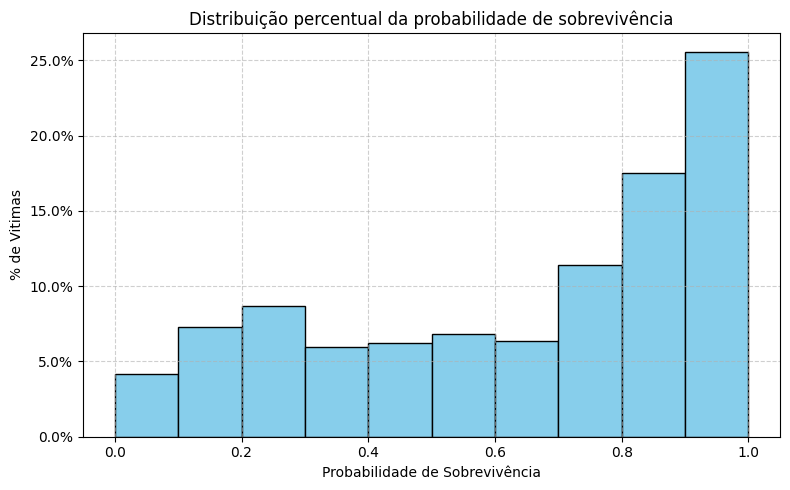

In [2]:
# Parâmetros do dataset (fixos para o trabalho)
N_VITIMAS = 6000
MEDIA_IDADE = 55
DESVIO_IDADE = 8
TIPO_ACIDENTE = "aereo"
NIVEL_RUIDO = 0.07
SEED_TREINO = 50
SEED_TESTE = 89

# Dataset de treino/validação
df_treino_val = gerar_dataset_vitimas(
    n_vitimas=N_VITIMAS,
    media_idade=MEDIA_IDADE,
    desvio_idade=DESVIO_IDADE,
    tipo_acidente=TIPO_ACIDENTE,
    nivel_ruido=NIVEL_RUIDO,
    seed=SEED_TREINO
)

In [3]:
print("Formato do dataset:", df_treino_val.shape)

print(df_treino_val.dtypes)

display(df_treino_val.head())

display(df_treino_val.describe())

Formato do dataset: (6000, 14)
idade      int64
fc         int64
fr         int64
pas        int64
spo2       int64
temp     float64
pr         int64
sg         int64
fx         int64
queim      int64
gcs        int64
avpu       int64
tri        int64
sobr     float64
dtype: object


,idade,fc,fr,pas,spo2,temp,pr,sg,fx,queim,gcs,avpu,tri,sobr
0,54,112,24,105,93,37.747571,0,2,1,0,13,0,1,0.90
1,61,129,28,85,98,37.517449,0,1,1,0,13,0,1,0.89
2,58,106,19,99,86,36.882684,1,2,1,0,13,1,1,0.76
3,67,110,25,87,90,38.323400,0,1,0,1,13,1,1,0.86
4,70,117,22,100,96,37.801619,0,1,0,0,13,1,1,0.68


,idade,fc,fr,pas,spo2,temp,pr,sg,fx,queim,gcs,avpu,tri,sobr
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,54.656667,104.503833,25.449833,83.018167,82.712500,35.404802,0.337333,1.977333,0.794833,0.843000,11.227333,1.272000,1.433333,0.639628
std,8.781874,43.207196,12.462559,33.971172,19.114272,2.700660,0.472839,1.193618,0.403857,1.218441,3.184600,1.049222,0.935967,0.297620
min,22.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,49.000000,88.000000,17.000000,70.000000,79.000000,34.161480,0.000000,1.000000,1.000000,0.000000,10.000000,0.000000,1.000000,0.380000
50%,54.000000,113.000000,26.000000,88.000000,87.000000,35.697765,0.000000,3.000000,1.000000,0.000000,11.000000,2.000000,2.000000,0.740000
75%,61.000000,135.000000,36.000000,107.000000,94.000000,37.383626,1.000000,3.000000,1.000000,2.000000,13.000000,2.000000,2.000000,0.900000
max,83.000000,173.000000,47.000000,143.000000,100.000000,39.607864,1.000000,3.000000,1.000000,3.000000,15.000000,3.000000,3.000000,1.000000


In [4]:
# variável alvo (target)
y = df_treino_val["sobr"]

# colunas proibidas pelo trabalho
colunas_proibidas = ["gcs", "avpu", "tri", "sobr"]

# features (entradas)
X = df_treino_val.drop(columns=colunas_proibidas)

print("Features utilizadas:")
print(list(X.columns))

print("\nFormato de X:", X.shape)
print("Formato de y:", y.shape)

Features utilizadas:
['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']

Formato de X: (6000, 10)
Formato de y: (6000,)


CART

Validação Cruzada

In [6]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# 1. Configurar a Validação Cruzada (K-Fold)
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=SEED_TREINO)

# 2. Definir 3 hiperparametrizações para o CART
hiperparametros_cart = [
    {"max_depth": 5, "min_samples_leaf": 10, "criterion": "squared_error"},
    {"max_depth": 10, "min_samples_leaf": 20, "criterion": "squared_error"},
    {"max_depth": 15, "min_samples_leaf": 5, "criterion": "friedman_mse"}
]

resultados_cart = []

print(f"Executando Validação Cruzada ({k_folds} folds) para o CART...\n")

for i, params in enumerate(hiperparametros_cart):
    model = DecisionTreeRegressor(**params, random_state=SEED_TREINO)
    
    # cross_validate retorna os scores de treino e validação para cada fold
    cv_results = cross_validate(
        model, X, y, 
        cv=kf, 
        scoring="neg_mean_squared_error", 
        return_train_score=True
    )
    
    # O sklearn retorna MSE negativo, inverte o sinal
    mse_treino = -cv_results["train_score"]
    mse_valida = -cv_results["test_score"]
    
    res = {
        "config": params,
        "mse_treino_medio": np.mean(mse_treino),
        "mse_valida_medio": np.mean(mse_valida),
        "var_treino": np.var(mse_treino),
        "var_valida": np.var(mse_valida)
    }
    resultados_cart.append(res)
    
    print(f"Configuração {i+1}: {params}")
    print(f"  MSE Treino Médio: {res['mse_treino_medio']:.6f}")
    print(f"  MSE Validação Médio: {res['mse_valida_medio']:.6f}")
    print(f"  Diferença Abs (Viés): {abs(res['mse_treino_medio'] - res['mse_valida_medio']):.6f}")
    print("-" * 30)

# Encontrar a melhor configuração baseada no MSE de validação
melhor_cart = min(resultados_cart, key=lambda x: x["mse_valida_medio"])
print(f"\nMELHOR CART: {melhor_cart['config']}")
print(f"MSE Validação: {melhor_cart['mse_valida_medio']:.6f}")

Executando Validação Cruzada (5 folds) para o CART...

Configuração 1: {'max_depth': 5, 'min_samples_leaf': 10, 'criterion': 'squared_error'}
  MSE Treino Médio: 0.017000
  MSE Validação Médio: 0.017923
  Diferença Abs (Viés): 0.000924
------------------------------
Configuração 2: {'max_depth': 10, 'min_samples_leaf': 20, 'criterion': 'squared_error'}
  MSE Treino Médio: 0.015643
  MSE Validação Médio: 0.019461
  Diferença Abs (Viés): 0.003818
------------------------------
Configuração 3: {'max_depth': 15, 'min_samples_leaf': 5, 'criterion': 'friedman_mse'}
  MSE Treino Médio: 0.010974
  MSE Validação Médio: 0.025109
  Diferença Abs (Viés): 0.014135
------------------------------

MELHOR CART: {'max_depth': 5, 'min_samples_leaf': 10, 'criterion': 'squared_error'}
MSE Validação: 0.017923
